In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [57]:
# Make the corner plot for the MCMC results
system_name = 'J0659'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [58]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,1.000000e+30,390.8237,-2.360459,0.825575,0.003924,28.05950
1,1.000000e+30,390.8277,-2.361223,0.824920,0.003897,27.98100
2,1.000000e+30,390.8280,-2.355318,0.826371,0.005623,28.01368
3,1.000000e+30,390.8955,-2.356279,0.821381,0.008347,28.08520
4,1.000000e+30,390.9741,-2.354013,0.818095,0.009120,28.13095
...,...,...,...,...,...,...
1973,4.429992e+02,383.6120,-1.711891,0.932017,0.424754,23.14836
1974,4.423022e+02,383.5759,-1.706397,0.932956,0.428664,23.12851
1975,4.432216e+02,383.5015,-1.707516,0.928404,0.424372,23.12176
1976,4.430171e+02,383.3973,-1.708718,0.931073,0.424780,23.16946


In [59]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [60]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

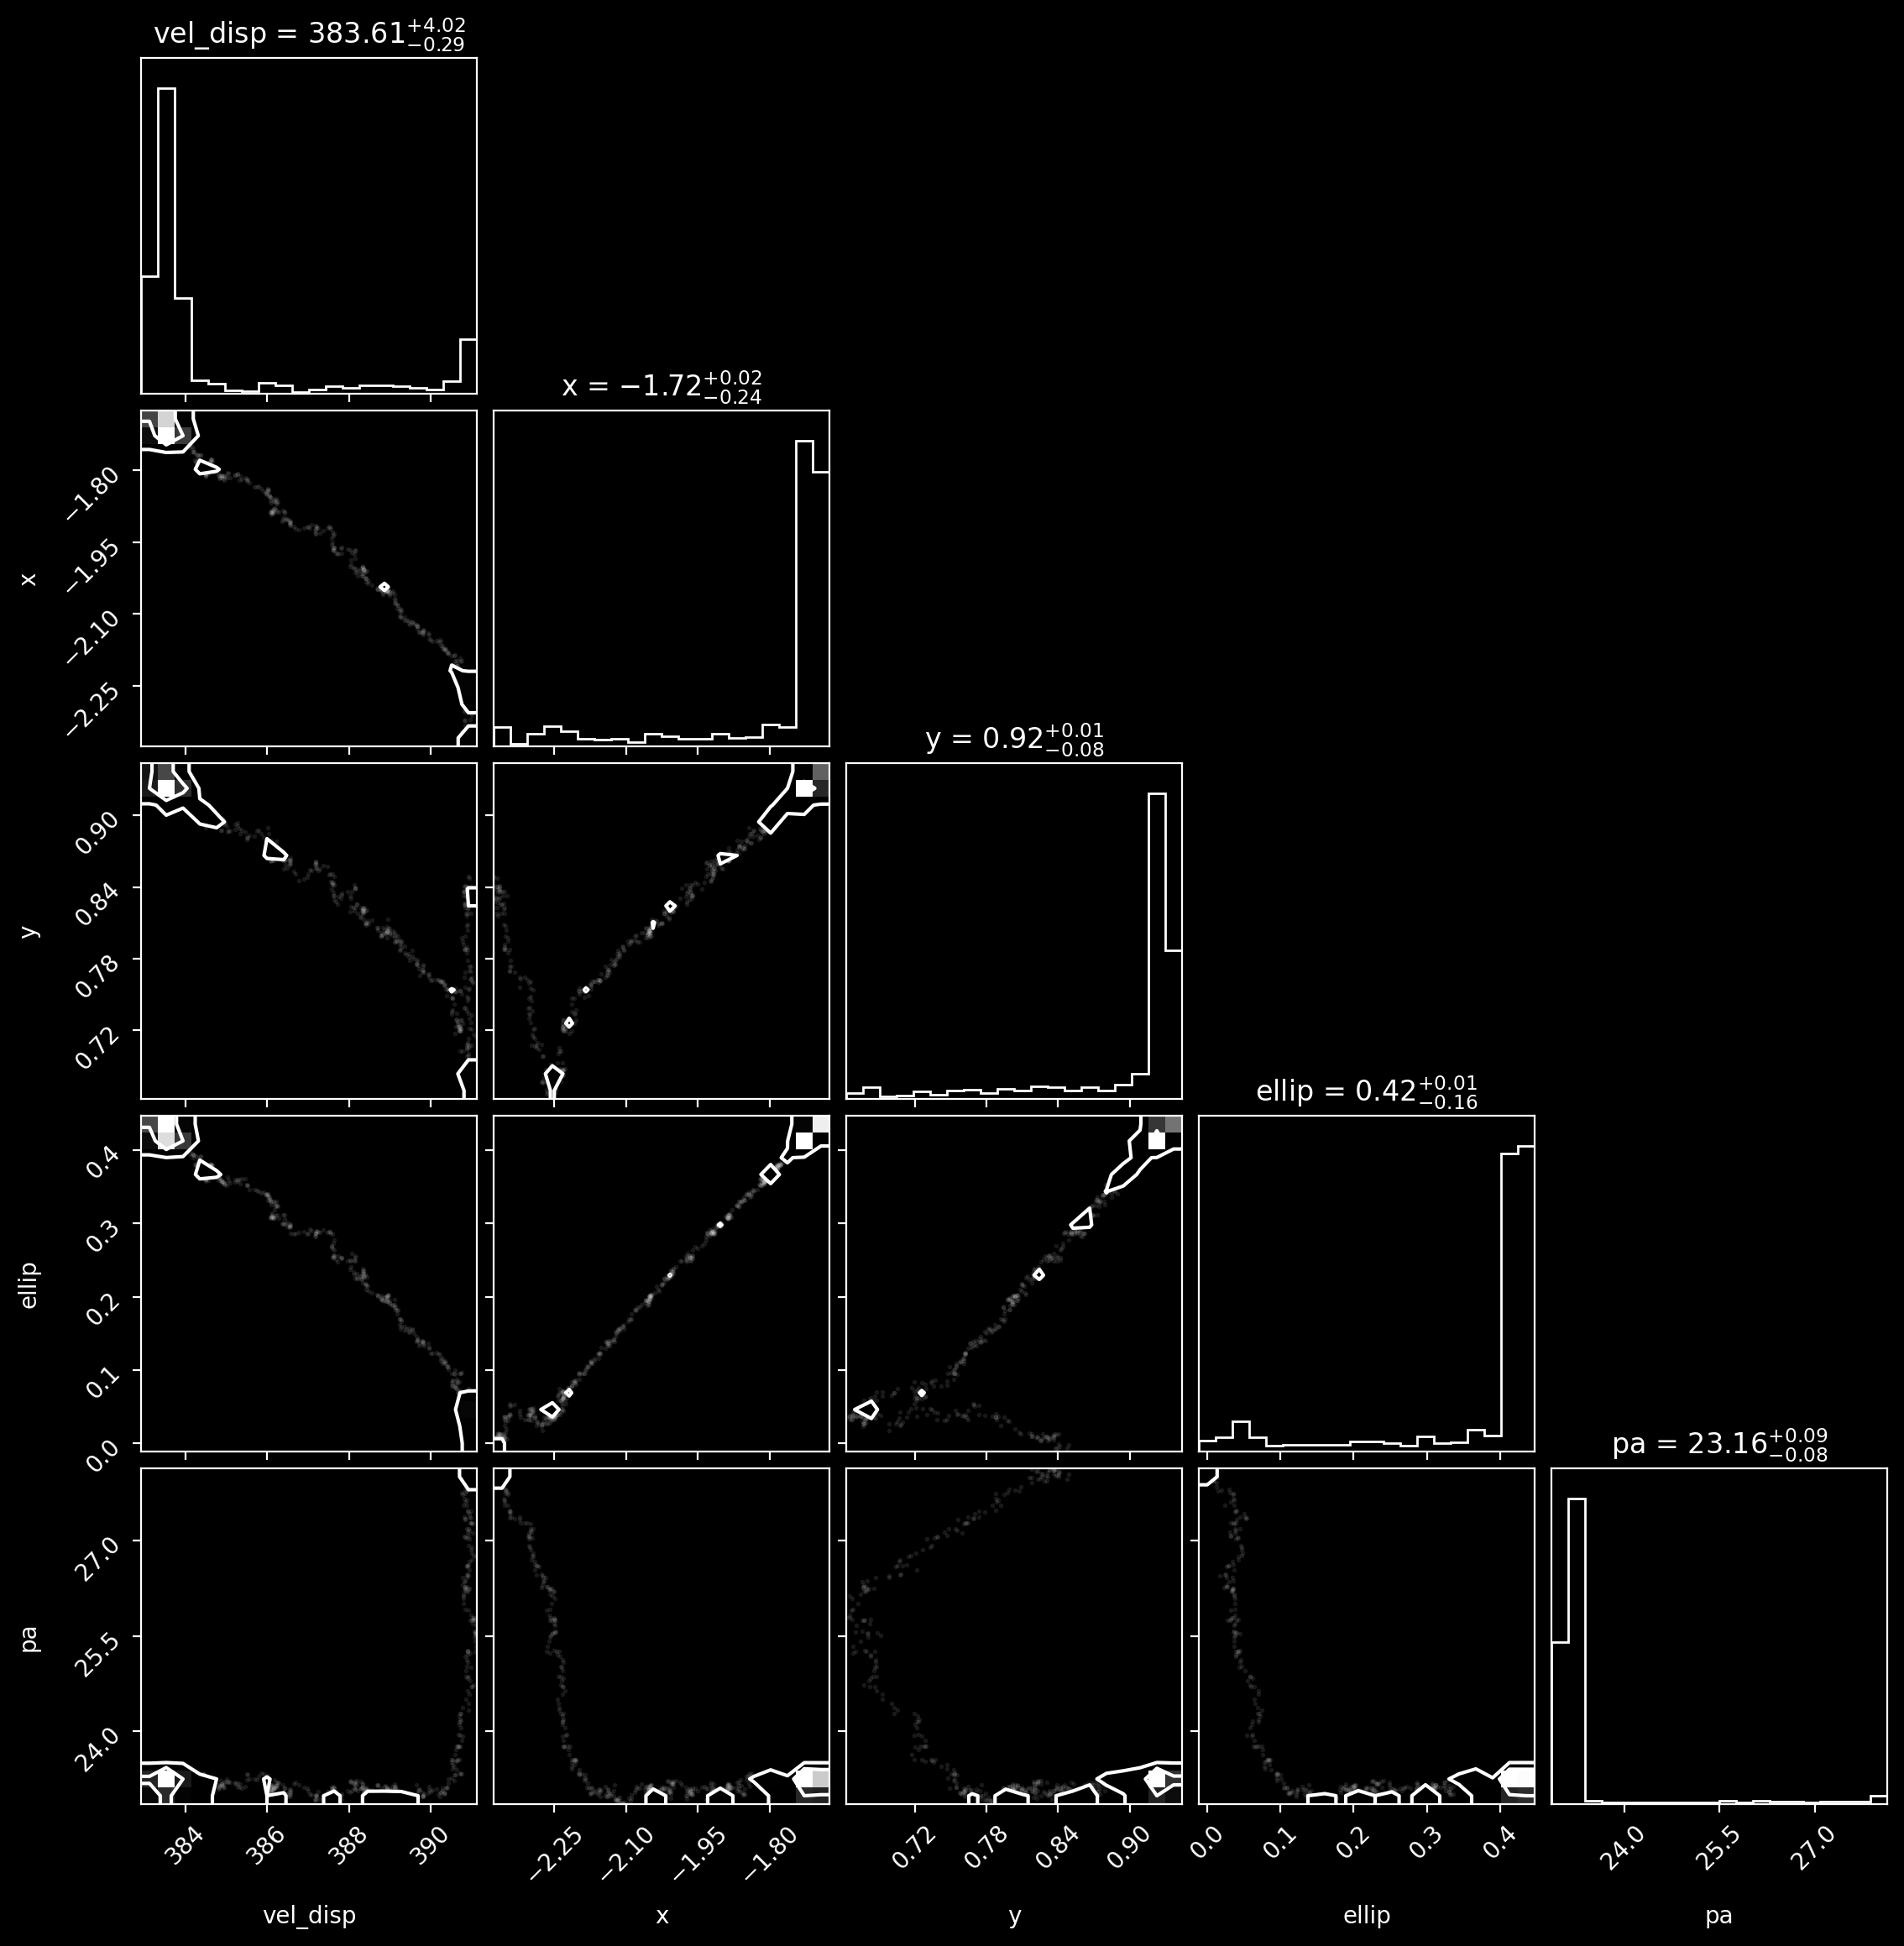

In [61]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')